# FFT Analysis

In [1]:
# create a new environment and run: pip install numpy scipy matplotlib
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

### Read CSV file signal-original.csv and read into array

In [2]:
signal = []
with open('signal-original.csv', 'r') as f:
    for line in f:
        signal.append(float(line.strip()))

print(f"Read {len(signal)} samples from signal-original.csv")

# Sample rate is 50 Hz
sample_rate = 50.0


Read 256 samples from signal-original.csv


### Plot original signal

In [ ]:
# Create a time vector
sample_count = len(signal)
t = np.linspace(0, sample_count/sample_rate, sample_count)

import plotly.graph_objects as go

fig = go.Figure(
    data=go.Scatter(
        x=t,
        y=signal,
        mode='lines+markers',
        name='Signal',
        marker=dict(size=5)
    )
)

fig.update_layout(
    title='Signal',
    xaxis_title='Time (s)',
    yaxis_title='Amplitude',
    xaxis=dict(rangeslider=dict(visible=True)),
    hovermode='x unified'
)

fig.show()

### Perform and plot FFT

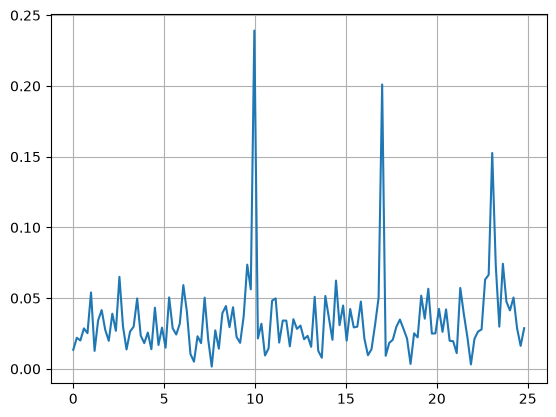

In [5]:
# Compute FFT
N = len(signal)
T = 1.0 / sample_rate
x = np.linspace(0.0, N*T, N, endpoint=False)
yf = fft(signal)
xf = fftfreq(N, T)[:N//2]

# Plot FFT
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.grid()
plt.show()

### FIR Filter Design

Filter designed using [Online FIR Filter Design Tool](http://t-filter.engineerjs.com/)

![Filter Settings](img/filter-parameters.png)
![Filter Curve](img/filter-curve.png)

In [6]:
filter_coeffs = [0.141461282,
-0.121417809,
-0.148241605,
0.00695722,
0.28543088,
0.428202751,
0.28543088,
0.00695722,
-0.148241605,
-0.121417809,
0.141461282]

### Apply FIR Filter using convolution

In [7]:
filtered_signal = np.convolve(signal, filter_coeffs, mode='same')

### Plot filtered signal

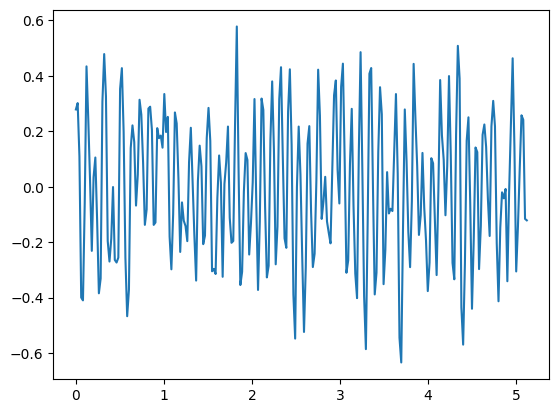

In [8]:
plt.plot(t, filtered_signal)

### Plot FFT of filtered signal

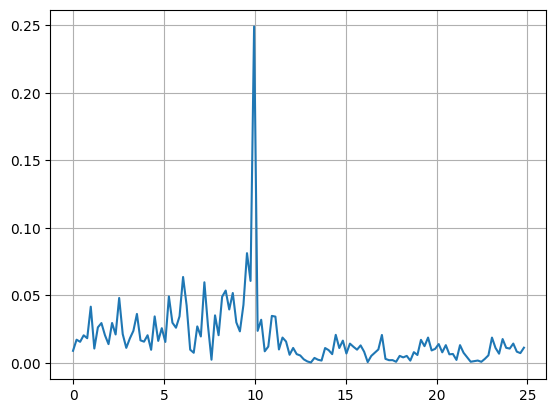

In [9]:
yf_filtered = fft(filtered_signal)
xf_filtered = fftfreq(len(filtered_signal), T)[:N//2]
plt.plot(xf_filtered, 2.0/N * np.abs(yf_filtered[0:N//2]))
plt.grid()
plt.show()